# Topology tests — winding number and Chern marker

Real-space topological invariants computed via `get_W` (1D winding number)
and `get_C` (2D Chern marker).  Both functions auto-derive their coordinate
functions from `H.geometry_uc` and build the position / σₓ operators
automatically for sublattice models.

In [2]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

## 1. SSH chain — real-space winding number

The SSH model has two sublattice atoms per unit cell with hoppings

    t₁ = t + δ   (intra-cell)
    t₂ = t − δ   (inter-cell)

- **δ < 0** ( t₂ > t₁ ): topological phase, winding number **W = 1**
- **δ > 0** ( t₁ > t₂ ): trivial phase, winding number **W = 0**

We sweep δ/t across the transition and evaluate the real-space winding-number
marker `get_W(H)` at the central unit cell.
`σ_z` and `xfunc` are both auto-derived from `H.geometry_uc`.

In [8]:
L_ssh = 6            # 2⁴ = 16 unit cells, 32 physical sites
t0    = 1.0
Ncheb = 150
mdim  = 60

# δ/t sweep: skip |δ| < 0.05 where the gap closes
deltas = vcat(range(-0.85, 0.85; length=50))
W_vals = Float64[]

for d in deltas
    H    = TensorBinding.get_Hamiltonian("ssh_sublattice", (t=t0, d=d); L=L_ssh)
    W_cl = TensorBinding.get_W(H; method=:mcweeny, maxdim=mdim,
                                 l=L_ssh, Λ=10)
    uc_c = H.N ÷ 2 + 1   # centre unit cell (1-indexed)
    push!(W_vals, real(W_cl(uc_c)))
    println("δ = ", lpad(round(d; digits=3), 6), "   W = ", round(W_vals[end]; digits=4))
end

δ =  -0.85   W = -0.9985
δ = -0.815   W = -0.9972
δ = -0.781   W = -0.9982
δ = -0.746   W = -0.9974
δ = -0.711   W = -0.9983
δ = -0.677   W = -0.9968
δ = -0.642   W = -0.9979
δ = -0.607   W = -0.9967
δ = -0.572   W = -0.9975
δ = -0.538   W = -0.9978
δ = -0.503   W = -0.9978
δ = -0.468   W = -0.9982
δ = -0.434   W = -0.9975
δ = -0.399   W = -0.998
δ = -0.364   W = -0.9973
δ =  -0.33   W = -0.997
δ = -0.295   W = -0.9966
δ =  -0.26   W = -0.9961
δ = -0.226   W = -0.9962
δ = -0.191   W = -0.9948
δ = -0.156   W = -0.9929
δ = -0.121   W = -0.9905
δ = -0.087   W = -0.9856
δ = -0.052   W = -0.9615
δ = -0.017   W = -0.6499
δ =  0.017   W = -0.1024
δ =  0.052   W = -0.02
δ =  0.087   W = -0.0063
δ =  0.121   W = -0.003
δ =  0.156   W = -0.0012
δ =  0.191   W = -0.0009
δ =  0.226   W = -0.0002
δ =   0.26   W = -0.0003
δ =  0.295   W = -0.0002
δ =   0.33   W = -0.0001
δ =  0.364   W = -0.0001
δ =  0.399   W = -0.0
δ =  0.434   W = 0.0001
δ =  0.468   W = 0.0
δ =  0.503   W = -0.0001
δ =  0.538   

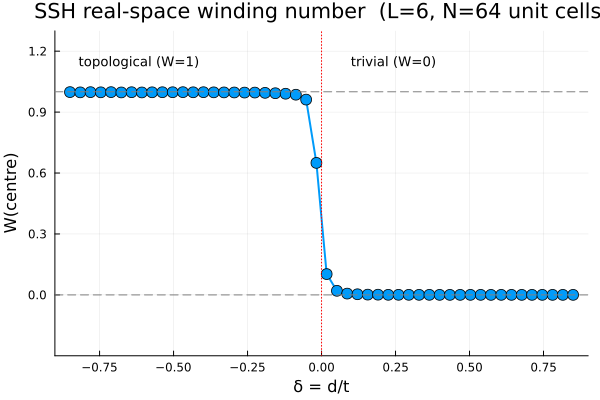

In [9]:
p = plot(deltas, -W_vals;
         xlabel="δ = d/t",
         ylabel="W(centre)",
         title="SSH real-space winding number  (L=$L_ssh, N=$(2^L_ssh) unit cells)",
         lw=2, marker=:circle, markersize=6, legend=false,
         ylims=(-0.3, 1.3))
hline!([0.0, 1.0]; linestyle=:dash, color=:gray, lw=1)
vline!([0.0];      linestyle=:dot,  color=:red,  lw=1)
annotate!(-0.82, 1.15, text("topological (W=1)", 9, :left))
annotate!( 0.10, 1.15, text("trivial (W=0)",     9, :left))
p

## 2. Haldane model — real-space Chern marker

Honeycomb lattice with nearest-neighbour (NN) hopping t₁ and complex
next-nearest-neighbour (NNN) hoppings t₂ e^{±iφ} (Haldane 1988).
At φ = π/2 and t₂/t₁ small the system is a Chern insulator with **|C| = 1**.

We build the model exactly as in `test_geometries` and then compute the
real-space Chern marker `get_C(H)` at the central unit cell.
`xfunc` and `yfunc` are auto-derived from `H.geometry_uc`.

In [8]:
Lx_h, Ly_h   = 4, 4
t1, t2, phi  = 1.0, 0.1, pi/2

H_hald = TensorBinding.get_Hamiltonian("honeycomb", (t=t1,);
                                        L=Lx_h+Ly_h, Lx=Lx_h, Ly=Ly_h)

# Six canonical NNN bonds: A→A (+φ), B→B (−φ)
# Phase signs determined by the Haldane chirality convention
haldane_phases = Dict(
    (1, 0,1,1) =>  1,   (0, 1,1,1) => -1,   (1,-1,1,1) => -1,
    (1, 0,2,2) => -1,   (0, 1,2,2) =>  1,   (1,-1,2,2) =>  1,
)
TensorBinding.add_hopping_2D!(H_hald,
    (dx,dy,fs,ts) -> t2 * exp(im * phi * get(haldane_phases, (dx,dy,fs,ts), 0));
    Lx=Lx_h, Ly=Ly_h, nn=2)

TBHamiltonian | L=8, N=256 +2sublattices, scale=auto, maxlinkdim=7 | geometry: 256 sites, 2D | no Tn cache

In [ ]:
M_hald = TensorBinding.get_matrix(H_hald.mpo, H_hald.sites)
println("max |M − M†| = ", maximum(abs.(M_hald - M_hald')))

function geometry_matrix(H)
    n_sub   = H.sublattice_s === nothing ? 1 : ITensors.dim(H.sublattice_s)
    N_atoms = n_sub * H.N
    rs      = Matrix{Float64}(undef, N_atoms, 2)
    for i in 1:N_atoms; rs[i, :] = H.geometry(i); end
    return rs
end

function plot_bonds_physical(M, rs; title="", threshold=0.3, simplify=true, n_sub=1)
    xs_p = rs[:, 1]
    ys_p = rs[:, 2]
    N    = size(rs, 1)
    plt  = plot(; title=title, aspect_ratio=:equal, legend=false, axis=false, grid=false)
    use_arrows = maximum(abs.(imag.(M))) > 1e-3
    sub_colors = [:darkorange, :mediumpurple, :seagreen, :crimson]
    for i in 1:N, j in i+1:N
        mij = M[i, j]
        abs(mij) > threshold || continue
        xi, yi = xs_p[i], ys_p[i]
        xj, yj = xs_p[j], ys_p[j]
        plot!(plt, [xi, xj], [yi, yj]; color=:gray, linewidth=2, alpha=0.8)
        if use_arrows && abs(imag(mij)) > 1e-4
            si = ((i-1) % n_sub) + 1
            sj = ((j-1) % n_sub) + 1
            col = (n_sub > 1 && si == sj) ? sub_colors[si] : :darkorange
            dx, dy = imag(mij) > 0 ? (xi - xj, yi - yj) : (xj - xi, yj - yi)
            blen  = sqrt(dx^2 + dy^2)
            ux, uy = dx/blen, dy/blen
            half   = blen * 0.22
            mx, my = (xi + xj)/2, (yi + yj)/2
            plot!(plt, [mx - half*ux, mx + half*ux], [my - half*uy, my + half*uy];
                  color=col, linewidth=2.5, alpha=0.95, arrow=true)
        end
    end
    scatter!(plt, xs_p, ys_p;
             markersize=simplify ? 10 : 4, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5)
    return plt
end

p1 = plot_bonds_physical(M_hald, geometry_matrix(H_hald);
         simplify=false, threshold=0.05, n_sub=2, title="Haldane Re(H)")

In [13]:
# Central unit cell: (ix, iy) = (Lx_uc÷2, Ly_uc÷2) in row-major layout
Lx_uc    = 2^Lx_h                                 # 4 UCs along x
Ly_uc    = 2^Ly_h                                 # 4 UCs along y
n_cell_c = (Ly_uc ÷ 2) * Lx_uc + (Lx_uc ÷ 2)    # 0-indexed UC number
uc_c_hald = n_cell_c + 1                          # 1-indexed UC number
mdim_h = 1000

println("Centre UC: ", n_cell_c, "  (ix=", n_cell_c % Lx_uc, ", iy=", n_cell_c ÷ Lx_uc, ")")
println("Centre position: ", round.(H_hald.geometry_uc(n_cell_c * 2 + 1); digits=3))

C_at     = TensorBinding.get_C(H_hald; method=:mcweeny,
                                maxdim=mdim_h, l=Lx_h, Λ=10)
C_center = real(C_at(uc_c_hald))
println("
Chern marker at centre: ", round(C_center; digits=4),
        "   (expected ≈ ±1 for Haldane topological phase)")

Centre UC: 136  (ix=8, iy=8)
Centre position: [12.0, 6.928]
Quenched operator products done
C1 done
C2 done
C3 done
C4 done

Chern marker at centre: 1.0252   (expected ≈ ±1 for Haldane topological phase)


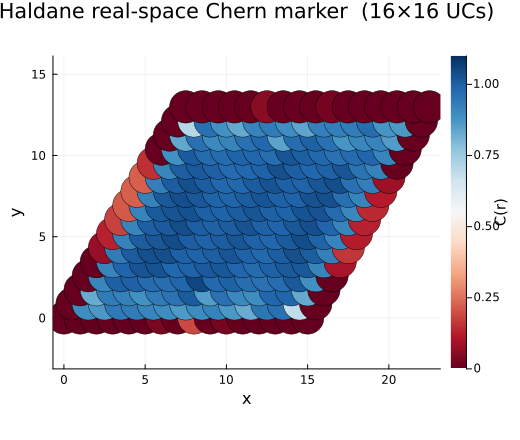

In [14]:
# Real-space Chern marker map over all unit cells
N_uc = 2^(Lx_h + Ly_h)   # 16 UCs for Lx_h=Ly_h=2

# UC uc (1-indexed) -> A-sublattice physical site -> Bravais position
uc_pos  = [H_hald.geometry_uc((uc - 1) * 2 + 1) for uc in 1:N_uc]
C_vals  = [real(C_at(uc)) for uc in 1:N_uc]

xs = [p[1] for p in uc_pos]
ys = [p[2] for p in uc_pos]

scatter(xs, ys;
    marker_z          = C_vals,
    color             = :RdBu,
    markersize        = 18,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C(r)",
    clims             = (0., 1.1),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "Haldane real-space Chern marker  ($(2^Lx_h)×$(2^Ly_h) UCs)",
    xlabel            = "x",
    ylabel            = "y",
    size              = (520, 440))


---
## 3. Thouless charge pump — AAH quasicrystal

The Aubry-André-Harper model with $\phi$ as the adiabatic parameter:
$$H(\phi) = -t\sum_{\langle i,j\rangle} c_i^\dagger c_j
            + V\sum_i \cos(2\pi b\,i + \phi)\,n_i$$

Sweeping $\phi: 0\to 2\pi$ pumps exactly one charge per cycle (Chern number = 1).
`thouless_pump` computes the $M_1Q$ adiabatic invariant from a sequence
of density matrices $P(\phi_k)$ computed via McWeeny purification.

---
## 1. System parameters

`L = 5` gives $N = 32$ sites.  We work in the **extended phase** ($V < 2t$) where
the ground state is gapped at half-filling due to the quasiperiodic structure.
The analytic scale estimate $(t + V) \times 1.2$ is set at construction to avoid
a DMRG call inside every `mcweeny_purify`.

In [70]:
L_pump   = 5
N_pump   = 2^L_pump          # 32 sites
t_pump   = 1.0
V_pump   = 2.0               # quasiperiodic amplitude (< 2t → extended/gapped)
b_pump   = 1/3               # modulation periodicity; tune to get different Chern numbers
ϵF_pump  = -1.3              # Fermi energy targeting the lower third of the spectrum ≈ [-4, 4]
Ne_pump  = N_pump ÷ 2        # half-filling reference

# φ sweeps [0, 2π) in Nt evenly-spaced steps
Nt_pump  = 200
T_pump   = 2π
dt_pump  = T_pump / Nt_pump
phi_vals = [k * dt_pump for k in 0:(Nt_pump - 1)]

scale_pump = (2t_pump + V_pump) * 1.2

# Build once to obtain shared site indices; all H_k reuse them via ref_sites
_H_ref     = TensorBinding.get_Hamiltonian(
    "aah", (V=V_pump, phi=0.0, t=t_pump, b=b_pump); L=L_pump, scale=scale_pump)
pump_sites = _H_ref.sites

# Factory: b is passed inside the params NamedTuple so it reaches HAAH via mparam_dict
H_aah_of_phi(phi) = TensorBinding.get_Hamiltonian(
    "aah", (V=V_pump, phi=phi, t=t_pump, b=b_pump); L=L_pump, scale=scale_pump,
    ref_sites=pump_sites)

xfunc(i, N) = Float64(i)
H0       = H_aah_of_phi(0.0)
x_op     = TensorBinding.get_pump_xop(H0.L, H0.sites, xfunc; quenched=false)
r_center = N_pump ÷ 2        # bulk central site for M1Q marker

println(H0)
println("b = $b_pump,  V = $V_pump,  ϵF = $ϵF_pump,  Nt = $Nt_pump,  r_c = $r_center")

TBHamiltonian | L=5, N=32, scale=4.8, maxlinkdim=5 | geometry: 32 sites, 1D | no Tn cache
b = 0.3333333333333333,  V = 2.0,  ϵF = -1.3,  Nt = 200,  r_c = 16


---
## 2. Wannier centre trajectory

At each phase step $\phi_k$ we:
1. Build $H(\phi_k)$ and compute $P(\phi_k)$ via McWeeny purification.
2. Store $P(\phi_k)$ in `P_array` for the Berry curvature integral.
3. Record $W(\phi_k) = \operatorname{Tr}[P\hat x] / N_e$.

In [71]:
maxdim_pump = 80
cutoff_pump = 1e-8

P_array = MPO[]
wannier  = Float64[]
npart    = Float64[]   # particle number check

for (k, phi) in enumerate(phi_vals)
    println("Step $k/$(Nt_pump): φ/π = $(round(phi/π; digits=3))")
    H_k = H_aah_of_phi(phi)
    P_k = TensorBinding.get_density(H_k; method=:mcweeny, ϵF=ϵF_pump,
              maxiters=50, maxdim=maxdim_pump, cutoff=cutoff_pump,
              tol=1e-6, verbose=false)
    push!(P_array, P_k)

    Ne_k = real(tr(P_k))
    Px_k = apply(P_k, x_op; maxdim=maxdim_pump, cutoff=cutoff_pump)
    W_k  = real(TensorBinding.matrix_checker(Px_k, H0.sites, r_center, r_center))

    push!(npart,   Ne_k)
    push!(wannier, W_k)
    println("  Tr(P) = $(round(Ne_k; digits=3))  W(r_c, φ) = $(round(W_k; digits=5))")
end

println("\nΔW local (r = $r_center) = ", round(wannier[end] - wannier[1]; digits=4))

Step 1/200: φ/π = 0.0
  Tr(P) = 11.0  W(r_c, φ) = 7.56128
Step 2/200: φ/π = 0.01
  Tr(P) = 11.0  W(r_c, φ) = 7.97847
Step 3/200: φ/π = 0.02
  Tr(P) = 11.0  W(r_c, φ) = 8.39745
Step 4/200: φ/π = 0.03
  Tr(P) = 11.0  W(r_c, φ) = 8.80762
Step 5/200: φ/π = 0.04
  Tr(P) = 11.0  W(r_c, φ) = 9.18102
Step 6/200: φ/π = 0.05
  Tr(P) = 11.0  W(r_c, φ) = 9.56483
Step 7/200: φ/π = 0.06
  Tr(P) = 11.0  W(r_c, φ) = 9.92679
Step 8/200: φ/π = 0.07
  Tr(P) = 11.0  W(r_c, φ) = 10.26858
Step 9/200: φ/π = 0.08
  Tr(P) = 11.0  W(r_c, φ) = 10.58023
Step 10/200: φ/π = 0.09
  Tr(P) = 11.0  W(r_c, φ) = 10.86426
Step 11/200: φ/π = 0.1
  Tr(P) = 11.0  W(r_c, φ) = 11.14937
Step 12/200: φ/π = 0.11
  Tr(P) = 11.0  W(r_c, φ) = 11.40368
Step 13/200: φ/π = 0.12
  Tr(P) = 11.0  W(r_c, φ) = 11.64063
Step 14/200: φ/π = 0.13
  Tr(P) = 11.0  W(r_c, φ) = 11.83661
Step 15/200: φ/π = 0.14
  Tr(P) = 11.0  W(r_c, φ) = 12.02699
Step 16/200: φ/π = 0.15
  Tr(P) = 11.0  W(r_c, φ) = 12.21055
Step 17/200: φ/π = 0.16
  Tr(P) = 11.0  W(

---
## 3. M1Q invariant → Chern number

Pass the pre-built `P_array` to `thouless_pump`, which:

1. Builds the adiabatic evolution operator $U(t)$ via the effective Hamiltonian
   $h(t) = [\dot P(t),\, P(t)]$ using a second-order Taylor step:
   $$U_k = \bigl(I + h_{k-1}\,\delta t + \tfrac{1}{2}h_{k-1}^2\,\delta t^2\bigr)\,U_{k-1}, \quad U_0 = I$$

2. Evaluates the local M1Q marker at the central site $r_c$:
   $$M_{1Q}(r_c,\,t) = \langle r_c|\,P(t)\,U^\dagger(t)\,\hat{x}\,U(t)\,P(t)\,|r_c\rangle$$

3. Returns $C = M_{1Q}(T) - M_{1Q}(0)$.

In [72]:
C_pump, M1Q_traj = TensorBinding.thouless_pump(P_array, dt_pump, x_op, H0.sites;
             r_center=r_center, maxdim=maxdim_pump, cutoff=cutoff_pump,
             verbose=true, return_trajectory=true)

println("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
println("Chern number C = M1Q(T) - M1Q(0) = ", round(C_pump; digits=4))
println("ΔW local (direct)               = ", round(wannier[end] - wannier[1]; digits=4))
println("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

M1Q(0) = 7.800222
  step 1/200  maxlinkdim(U) = 16
  step 2/200  maxlinkdim(U) = 16
  step 3/200  maxlinkdim(U) = 16
  step 4/200  maxlinkdim(U) = 16
  step 5/200  maxlinkdim(U) = 16
  step 6/200  maxlinkdim(U) = 16
  step 7/200  maxlinkdim(U) = 16
  step 8/200  maxlinkdim(U) = 16
  step 9/200  maxlinkdim(U) = 16
  step 10/200  maxlinkdim(U) = 16
  step 11/200  maxlinkdim(U) = 16
  step 12/200  maxlinkdim(U) = 16
  step 13/200  maxlinkdim(U) = 16
  step 14/200  maxlinkdim(U) = 16
  step 15/200  maxlinkdim(U) = 16
  step 16/200  maxlinkdim(U) = 16
  step 17/200  maxlinkdim(U) = 16
  step 18/200  maxlinkdim(U) = 16
  step 19/200  maxlinkdim(U) = 16
  step 20/200  maxlinkdim(U) = 16
  step 21/200  maxlinkdim(U) = 16
  step 22/200  maxlinkdim(U) = 16
  step 23/200  maxlinkdim(U) = 16
  step 24/200  maxlinkdim(U) = 16
  step 25/200  maxlinkdim(U) = 16
  step 26/200  maxlinkdim(U) = 16
  step 27/200  maxlinkdim(U) = 16
  step 28/200  maxlinkdim(U) = 16
  step 29/200  maxlinkdim(U) = 16
  ste

---
## 4. Plots

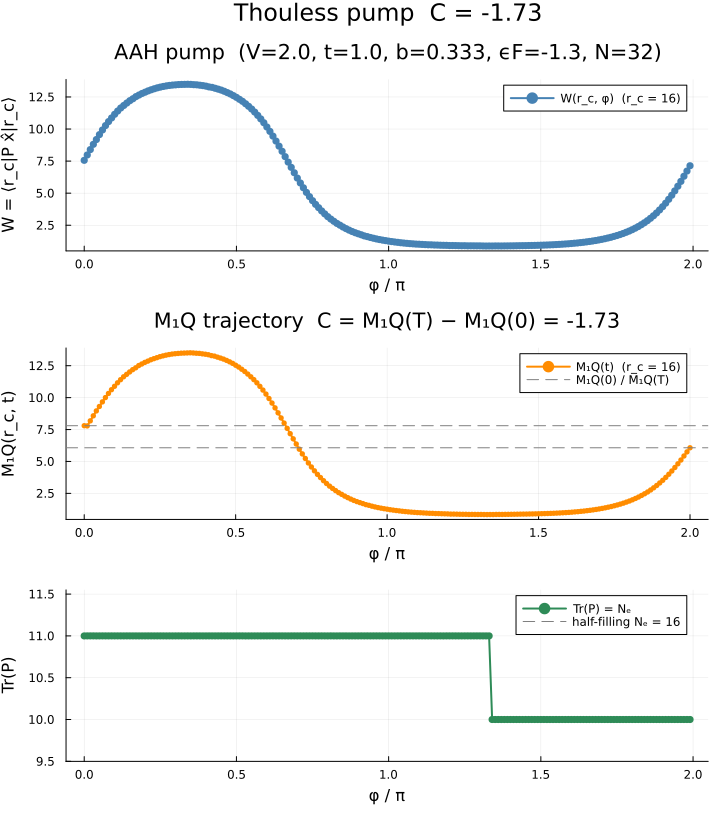

In [73]:
phi_axis      = phi_vals ./ π                              # Nt points ∈ [0, 2*(1-1/Nt))
phi_traj_axis = [k * dt_pump for k in 0:Nt_pump] ./ π    # Nt+1 points for M1Q trajectory

# ── Panel 1: local Wannier marker W(φ) ───────────────────────────────────────
p1 = plot(phi_axis, wannier;
     label="W(r_c, φ)  (r_c = $r_center)", lw=2, color=:steelblue,
     marker=:circle, ms=4, markerstrokewidth=0,
     xlabel="φ / π", ylabel="W = ⟨r_c|P x̂|r_c⟩",
     title="AAH pump  (V=$(V_pump), t=$(t_pump), b=$(round(b_pump;digits=3)), ϵF=$(ϵF_pump), N=$(N_pump))")

# ── Panel 2: M1Q(t) trajectory ───────────────────────────────────────────────
p2 = plot(phi_traj_axis, M1Q_traj;
     label="M₁Q(t)  (r_c = $r_center)", lw=2, color=:darkorange,
     marker=:circle, ms=3, markerstrokewidth=0,
     xlabel="φ / π", ylabel="M₁Q(r_c, t)",
     title="M₁Q trajectory  C = M₁Q(T) − M₁Q(0) = $(round(C_pump; digits=3))")
hline!(p2, [M1Q_traj[1], M1Q_traj[end]];
     ls=:dash, color=:gray, label="M₁Q(0) / M₁Q(T)")

# ── Panel 3: particle number Nₑ(φ) ───────────────────────────────────────────
p3 = plot(phi_axis, npart;
     label="Tr(P) = Nₑ", lw=2, color=:seagreen,
     marker=:circle, ms=4, markerstrokewidth=0,
     xlabel="φ / π", ylabel="Tr(P)",
     ylims=(minimum(npart) * 0.95, maximum(npart) * 1.05))
hline!(p3, [Ne_pump]; ls=:dash, color=:gray, label="half-filling Nₑ = $Ne_pump")

display(plot(p1, p2, p3;
     layout=(3, 1), size=(720, 820),
     plot_title="Thouless pump  C = $(round(C_pump; digits=3))"))

---
## 4. Graphene with Semenoff mass — valley Chern marker

A Semenoff mass M breaks inversion symmetry on the honeycomb lattice:

$$H = -t\sum_{\langle ij\rangle} c_i^\dagger c_j + M\sum_i \eta_i\, n_i, \qquad \eta_i = +1\;(A),\;-1\;(B)$$

This gaps the Dirac points while preserving time-reversal, so the total Chern
number is **C = 0**.  The two valleys carry opposite valley Chern numbers
**C_K = +1, C_K′ = −1** — the hallmark of a valley Hall insulator.

We use `get_valley_operator` to build the valley operator V (NNN Haldane
structure with sublattice sign, prefactor −i/3√3) and `get_valley_C` to
compute the real-space valley Chern marker at every unit cell.

In [2]:
Lx_s, Ly_s = 3, 3      # 16×16 = 256 unit cells
t_s  = 1.0
M_s  = 0.5             # Semenoff mass; gap = 2M at Dirac points

H_sem = TensorBinding.get_Hamiltonian("honeycomb", (t=t_s,);
                                       L=Lx_s+Ly_s, Lx=Lx_s, Ly=Ly_s)
TensorBinding.add_onsite!(H_sem, +M_s; sublat=1)   # +M on sublattice A
TensorBinding.add_onsite!(H_sem, -M_s; sublat=2)   # −M on sublattice B

println(H_sem)
println("Gap = 2M = ", 2M_s)

TBHamiltonian | L=6, N=64 +2sublattices, scale=auto, maxlinkdim=6 | geometry: 64 sites, 2D | no Tn cache
Gap = 2M = 1.0


In [ ]:
# Sanity check: eigenvalues of the valley operator V
# For a valid valley operator the spectrum should be ±1 (or scaled versions).
V_check = TensorBinding.get_valley_operator(H_sem)
M_V     = TensorBinding.get_matrix(V_check, H_sem.sites)
ev      = sort(real(eigvals(M_V)))
println("Unique eigenvalues of V (rounded to 2 dp):")
println(round.(ev; digits=2))

In [3]:
mdim_s = 800

# Purified P is cached in H_sem._density_cache after the first call and reused.
C_K_at = TensorBinding.get_valley_C(H_sem; sequential=false,
             valley=:K, method=:mcweeny, maxdim=mdim_s, l=Lx_s, Λ=15, cutoff=1e-8)
println("K valley done")

C_Kp_at = TensorBinding.get_valley_C(H_sem; sequential=false,
              valley=:K_prime, method=:mcweeny, maxdim=mdim_s, l=Lx_s, Λ=15, cutoff=1e-8)
println("K′ valley done")

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.9602,  E_max = 2.9602
  center = 0.0,  scale = 3.2562
Quenched operator products done
C1 done
C2 done
C3 done
C4 done
K valley done
Quenched operator products done
C1 done
C2 done
C3 done
C4 done
K′ valley done


C_K  bulk mean : NaN
C_K′ bulk mean : NaN


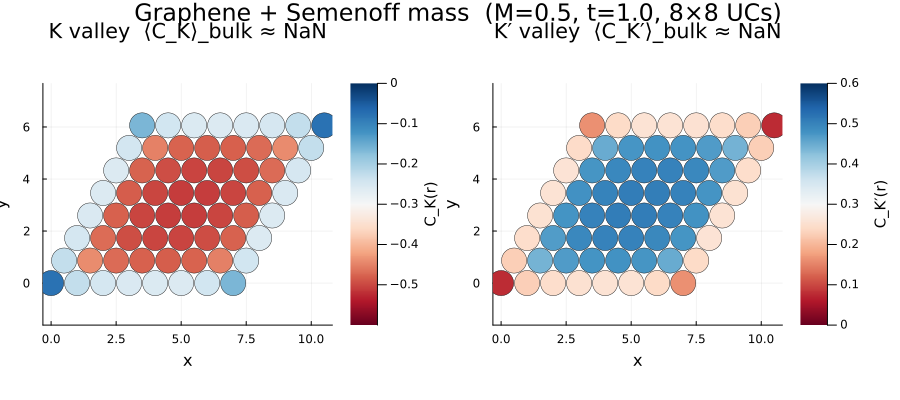

In [5]:
using Statistics

N_uc_s   = 2^(Lx_s + Ly_s)
Lx_uc_s  = 2^Lx_s
Ly_uc_s  = 2^Ly_s
uc_pos_s = [H_sem.geometry_uc((uc - 1) * 2 + 1) for uc in 1:N_uc_s]
xs_s     = [p[1] for p in uc_pos_s]
ys_s     = [p[2] for p in uc_pos_s]

CK_vals  = [real(C_K_at(uc))  for uc in 1:N_uc_s]
CKp_vals = [real(C_Kp_at(uc)) for uc in 1:N_uc_s]

# Bulk mask: exclude the outermost ring of unit cells
bulk = [ix >= 4 && ix <= Lx_uc_s-4 && iy >= 4 && iy <= Ly_uc_s-5
        for uc in 1:N_uc_s
        for (ix, iy) in [((uc-1) % Lx_uc_s, (uc-1) ÷ Lx_uc_s)]]

println("C_K  bulk mean : ", round(mean(CK_vals[bulk]);  digits=3))
println("C_K′ bulk mean : ", round(mean(CKp_vals[bulk]); digits=3))

clim_s = 0.6
p_K = scatter(xs_s, ys_s;
    marker_z          = 2*CK_vals,
    color             = :RdBu,
    markersize        = 14,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C_K(r)",
    clims             = (-clim_s, 0.),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "K valley  ⟨C_K⟩_bulk ≈ $(round(mean(CK_vals[bulk]); digits=3))",
    xlabel            = "x", ylabel = "y")

p_Kp = scatter(xs_s, ys_s;
    marker_z          = 2*CKp_vals,
    color             = :RdBu,
    markersize        = 14,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C_K′(r)",
    clims             = (0., clim_s),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "K′ valley  ⟨C_K′⟩_bulk ≈ $(round(mean(CKp_vals[bulk]); digits=3))",
    xlabel            = "x", ylabel = "y")

plot(p_K, p_Kp;
    layout     = (1, 2),
    size       = (900, 400),
    plot_title = "Graphene + Semenoff mass  (M=$M_s, t=$t_s, $(2^Lx_s)×$(2^Ly_s) UCs)")

---
## 5. Periodically buckled graphene — valley Chern marker

Honeycomb lattice with NN hopping $t$ plus a sinusoidal bond-strength
modulation:
$$\delta t_{ij} = A \sin(\mathbf{G}_n \cdot \mathbf{r}_{ij}^{\rm mid})$$

where $\mathbf{G}_n = \omega_0 \hat{g}_n$ points along each of the three
inequivalent NN bond directions and $\mathbf{r}_{ij}^{\rm mid}$ is the
bond midpoint.  The modulation breaks inversion symmetry and gaps the
Dirac points, giving opposite valley Chern numbers $C_K = -C_{K'} = \pm 1$,
while preserving time-reversal so the total Chern number remains **C = 0**.

In [ ]:
Lx_bg, Ly_bg = 4, 4
t1_bg  = 1.0
amp_bg = 0.2
Nx_bg, Ny_bg = 2^Lx_bg, 2^Ly_bg

H_bg = TensorBinding.get_Hamiltonian("honeycomb", (t=t1_bg,);
                                      L=Lx_bg+Ly_bg, Lx=Lx_bg, Ly=Ly_bg)
geom_bg   = H_bg.geometry
omega0_bg = 2π / Nx_bg * 2 / sqrt(3.0) * 2

G_vec = Dict(
    (0, 0, 1, 2) => omega0_bg .* normalize(geom_bg(2)              .- geom_bg(1)),
    (1, 0, 2, 1) => omega0_bg .* normalize(geom_bg(3)              .- geom_bg(2)),
    (0, 1, 2, 1) => omega0_bg .* normalize(geom_bg(2*Nx_bg + 1)    .- geom_bg(2)),
)

TensorBinding.add_hopping_2D!(H_bg,
    (ix, iy, dx, dy, fs, ts) -> begin
        haskey(G_vec, (dx, dy, fs, ts)) || return zero(ComplexF64)
        ix_s  = mod(ix - dx, Nx_bg)
        iy_s  = mod(iy - dy, Ny_bg)
        r_dst = geom_bg(2*(ix   +  iy  * Nx_bg) + ts)
        r_src = geom_bg(2*(ix_s + iy_s * Nx_bg) + fs)
        r_mid = 0.5 .* (r_src .+ r_dst)
        amp_bg * sin(dot(G_vec[(dx, dy, fs, ts)], r_mid))
    end;
    Lx=Lx_bg, Ly=Ly_bg, nn=1)

println(H_bg)
println("ω₀ = ", round(omega0_bg; digits=4), "   amp = ", amp_bg)

TBHamiltonian | L=8, N=256 +2sublattices, scale=auto, maxlinkdim=7 | geometry: 256 sites, 2D | no Tn cache
ω₀ = 1.8138   amp = 0.2


In [8]:
mdim_bg = 800

C_K_bg_at = TensorBinding.get_valley_C(H_bg; sequential=false,
                valley=:K, method=:mcweeny, fermi=0.2, maxdim=mdim_bg, l=Lx_bg, Λ=15, cutoff=1e-8)
println("K valley done")

C_Kp_bg_at = TensorBinding.get_valley_C(H_bg; sequential=false,
                 valley=:K_prime, method=:mcweeny, fermi=0.2, maxdim=mdim_bg, l=Lx_bg, Λ=15, cutoff=1e-8)
println("K′ valley done")

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -3.0412,  E_max = 3.0422
  center = 0.0005,  scale = 3.3458
Quenched operator products done
C1 done
C2 done
C3 done
C4 done
K valley done
Quenched operator products done
C1 done
C2 done
C3 done
C4 done
K′ valley done


C_K  bulk mean : -0.035
C_K′ bulk mean : 0.035


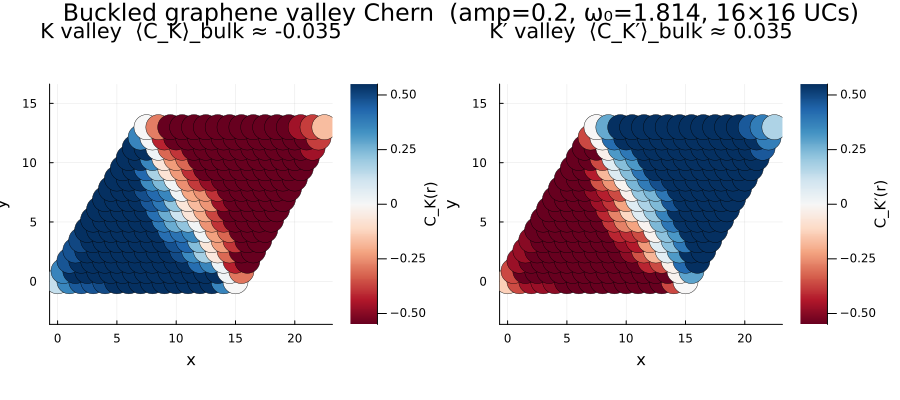

In [9]:
using Statistics

N_uc_bg   = 2^(Lx_bg + Ly_bg)
Lx_uc_bg  = 2^Lx_bg
Ly_uc_bg  = 2^Ly_bg
uc_pos_bg = [H_bg.geometry_uc((uc - 1) * 2 + 1) for uc in 1:N_uc_bg]
xs_bg     = [p[1] for p in uc_pos_bg]
ys_bg     = [p[2] for p in uc_pos_bg]

CK_bg_vals  = [real(C_K_bg_at(uc))  for uc in 1:N_uc_bg]
CKp_bg_vals = [real(C_Kp_bg_at(uc)) for uc in 1:N_uc_bg]

bulk_bg = [ix >= 4 && ix <= Lx_uc_bg-4 && iy >= 4 && iy <= Ly_uc_bg-5
           for uc in 1:N_uc_bg
           for (ix, iy) in [((uc-1) % Lx_uc_bg, (uc-1) ÷ Lx_uc_bg)]]

println("C_K  bulk mean : ", round(mean(CK_bg_vals[bulk_bg]);  digits=3))
println("C_K′ bulk mean : ", round(mean(CKp_bg_vals[bulk_bg]); digits=3))

clim_bg = 0.55
p_K_bg = scatter(xs_bg, ys_bg;
    marker_z          = 2 .* CK_bg_vals,
    color             = :RdBu,
    markersize        = 14,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C_K(r)",
    clims             = (-clim_bg, clim_bg),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "K valley  ⟨C_K⟩_bulk ≈ $(round(mean(CK_bg_vals[bulk_bg]); digits=3))",
    xlabel            = "x", ylabel = "y")

p_Kp_bg = scatter(xs_bg, ys_bg;
    marker_z          = 2 .* CKp_bg_vals,
    color             = :RdBu,
    markersize        = 14,
    markerstrokewidth = 0.5,
    markerstrokecolor = :black,
    colorbar          = true,
    colorbar_title    = "C_K′(r)",
    clims             = (-clim_bg, clim_bg),
    aspect_ratio      = :equal,
    legend            = false,
    title             = "K′ valley  ⟨C_K′⟩_bulk ≈ $(round(mean(CKp_bg_vals[bulk_bg]); digits=3))",
    xlabel            = "x", ylabel = "y")

plot(p_K_bg, p_Kp_bg;
    layout     = (1, 2),
    size       = (900, 400),
    plot_title = "Buckled graphene valley Chern  (amp=$(amp_bg), ω₀=$(round(omega0_bg; digits=3)), $(2^Lx_bg)×$(2^Ly_bg) UCs)")